El gráfico se guardó correctamente como 'airline_vergleich_spanien_2025.png'.


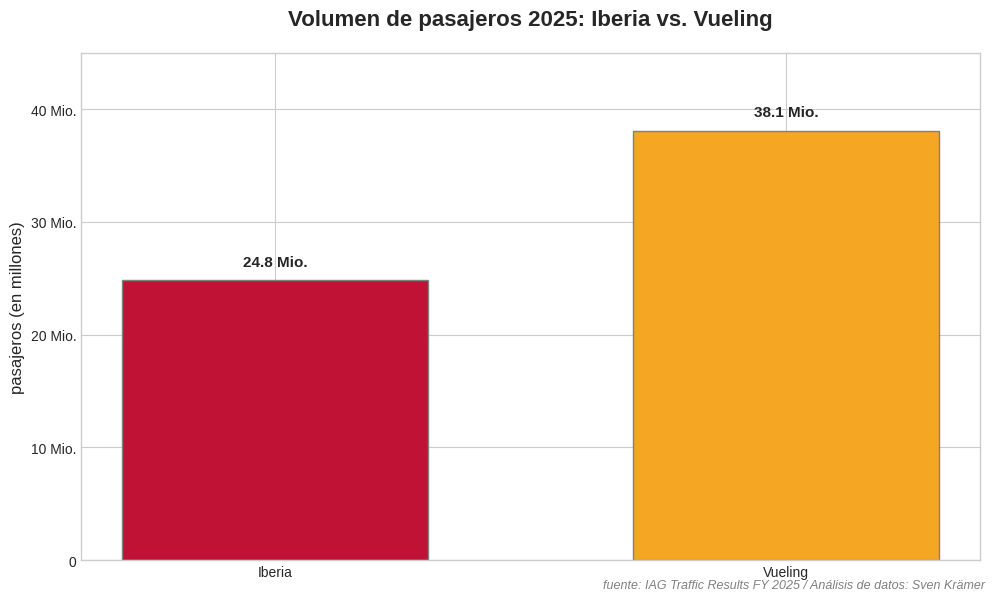

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Daten aus dem Screenshot (Total Year Passagierzahlen in Tausend)
# Wir runden die Zahlen für eine sauberere Darstellung
airlines = ['Iberia', 'Vueling']
passengers = [24823, 38100]  # Die Originalwerte: 24.823 und 38.100

# 2. Grafik-Setup
# Wir nutzen ein etwas schlichteres Design, das gut zu Blogposts passt
plt.style.use('seaborn-v0_8-whitegrid') 
fig, ax = plt.subplots(figsize=(10, 6))

# 3. Balken erstellen
# Wir nutzen die IAG-Farben (Iberia-Rot und Vueling-Gelb/Grau)
bar_colors = ['#C01235', '#F5A623'] # Ein Rot für Iberia und ein Gelb für Vueling
bars = ax.bar(airlines, passengers, color=bar_colors, edgecolor='grey', width=0.6)

# 4. Design-Details (Titel, Achsen, Beschriftungen)
ax.set_title('Volumen de pasajeros 2025: Iberia vs. Vueling', fontsize=16, fontweight='bold', pad=20)
ax.set_ylabel('pasajeros (en millones)', fontsize=12)
ax.set_ylim(0, 45000) # Etwas Platz nach oben lassen

# Die Y-Achse in Millionen umbeschriften, damit man nicht Tausender-Zahlen lesen muss
ax.set_yticks([0, 10000, 20000, 30000, 40000])
ax.set_yticklabels(['0', '10 Mio.', '20 Mio.', '30 Mio.', '40 Mio.'])

# 5. Zahlen direkt auf die Balken schreiben (für bessere Lesbarkeit)
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 1000,
            f'{height/1000:.1f} Mio.', # Umrechnung in Millionen mit einer Nachkommastelle
            ha='center', va='bottom', fontsize=11, fontweight='bold')

# 6. Fußzeile mit Datenquelle hinzufügen
plt.figtext(0.99, 0.01, 'fuente: IAG Traffic Results FY 2025 / Análisis de datos: Sven Krämer', 
            horizontalalignment='right', fontsize=9, style='italic', color='grey')

# 7. Layout optimieren und speichern
plt.tight_layout()
plt.savefig('Comparación_de_aerolíneas_España.png', dpi=300) # Hochauflösendes Bild speichern

print("El gráfico se guardó correctamente como 'airline_vergleich_spanien_2025.png'.")

In [3]:
from pymongo import MongoClient

# 1. Verbindung zur MongoDB auf deinem System
client = MongoClient("mongodb://localhost:27017/")
db = client.Espana  # Deine Datenbank
collection = db.airline_stats

# 2. Datenvorbereitung aus dem IAG-Bericht (Passagiere in Tausend)
# Wir legen eine Liste mit Dokumenten an
data = [
    # IBERIA
    {"airline": "Iberia", "jahr": 2025, "passagiere_tsd": 24823, "load_factor_pct": 87.2},
    {"airline": "Iberia", "jahr": 2024, "passagiere_tsd": 22108, "load_factor_pct": 86.3},
    
    # VUELING
    {"airline": "Vueling", "jahr": 2025, "passagiere_tsd": 38100, "load_factor_pct": 91.1},
    {"airline": "Vueling", "jahr": 2024, "passagiere_tsd": 38048, "load_factor_pct": 92.8},
    
    # LEVEL (Für den Langstrecken-Vergleich)
    {"airline": "Level", "jahr": 2025, "passagiere_tsd": 622, "load_factor_pct": 92.4},
    {"airline": "Level", "jahr": 2024, "passagiere_tsd": 517, "load_factor_pct": 94.4}
]

# 3. Daten in MongoDB einfügen
try:
    # Bestehende Daten löschen, falls du das Skript mehrfach ausführst (optional)
    # collection.delete_many({}) 
    
    result = collection.insert_many(data)
    print(f"Erfolgreich {len(result.inserted_ids)} Dokumente in 'airline_stats' eingefügt.")
    
except Exception as e:
    print(f"Fehler beim Import: {e}")

# 4. Kleiner Test-Check in der Konsole
sample = collection.find_one({"airline": "Vueling", "jahr": 2025})
if sample:
    print(f"Check: Vueling 2025 hat {sample['passagiere_tsd']} Tsd. Passagiere.")

Erfolgreich 6 Dokumente in 'airline_stats' eingefügt.
Check: Vueling 2025 hat 38100 Tsd. Passagiere.
